# Conversión de PCM 16-bit @ 44.1 kHz a DSD64 (1-bit)

Este módulo muestra cómo:

1. Generar una señal de audio **PCM** de 16 bits a **44.1 kHz**.
2. Convertirla a un flujo **DSD64** de **1 bit** usando un **modulador delta-sigma de primer orden**.
3. Visualizar la relación entre:
   - El PCM escalonado
   - El bitstream DSD (densidad de 0/1)
   - La onda senoidal “ideal”

Está pensado como material didáctico para entender la diferencia entre **PCM** y **DSD**.

---

## 1. Conceptos básicos

### PCM (Pulse Code Modulation)

- Frecuencia de muestreo: `Fs_pcm = 44_100 Hz`
- Profundidad de bits: `16 bits` (enteros en el rango −32768 … 32767).
- Cada muestra es un número que representa directamente la amplitud de la señal en ese instante.
- En la gráfica se ve como una **onda escalonada**.

### DSD (Direct Stream Digital)

- Frecuencia de muestreo: `Fs_dsd = Fs_pcm × OSR`
- En DSD64 se usa `OSR = 64`, por lo que:
  - `Fs_dsd = 44_100 × 64 = 2_822_400 Hz`
- Profundidad: **1 bit** (solo dos niveles, típicamente −1 y +1).
- La amplitud ya no se codifica con muchos bits, sino con la **densidad** de unos y ceros:
  - Más `1` (o +1) en zonas donde la señal es positiva.
  - Más `0` (o −1) en zonas donde la señal es negativa.
- Se genera con un **modulador delta-sigma**:
  - Integra el error entre la señal y la salida cuantizada.
  - “Empuja” el ruido de cuantización hacia altas frecuencias (fuera de banda audible).

---


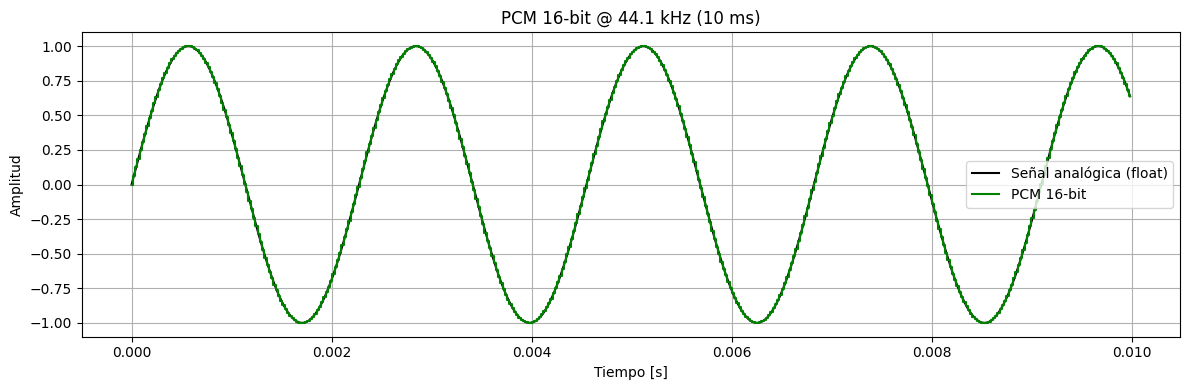

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# Parámetros de la señal PCM
# ============================================
Fs_pcm = 44100          # Frecuencia de muestreo PCM
duration = 0.01         # Duración de ejemplo: 10 ms
f = 440                 # Frecuencia de la señal de prueba (Hz)

# Tiempo discreto
N_pcm = int(Fs_pcm * duration)
t_pcm = np.linspace(0, duration, N_pcm, endpoint=False)

# Señal analógica ideal (en float, rango -1 a +1)
pcm_float = np.sin(2 * np.pi * f * t_pcm)

# Conversión a PCM de 16 bits (enteros)
pcm_16 = np.round(pcm_float * 32767).astype(np.int16)

# ===================== Gráfica =====================
plt.figure(figsize=(12,4))

# Señal “analógica” (float)
plt.plot(t_pcm, pcm_float, label="Señal analógica (float)", color='black')

# PCM escalonado (normalizado a [-1,1] para graficar)
plt.step(t_pcm, pcm_16 / 32767.0, where='mid',
         label="PCM 16-bit", color='green')

plt.title("PCM 16-bit @ 44.1 kHz (10 ms)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


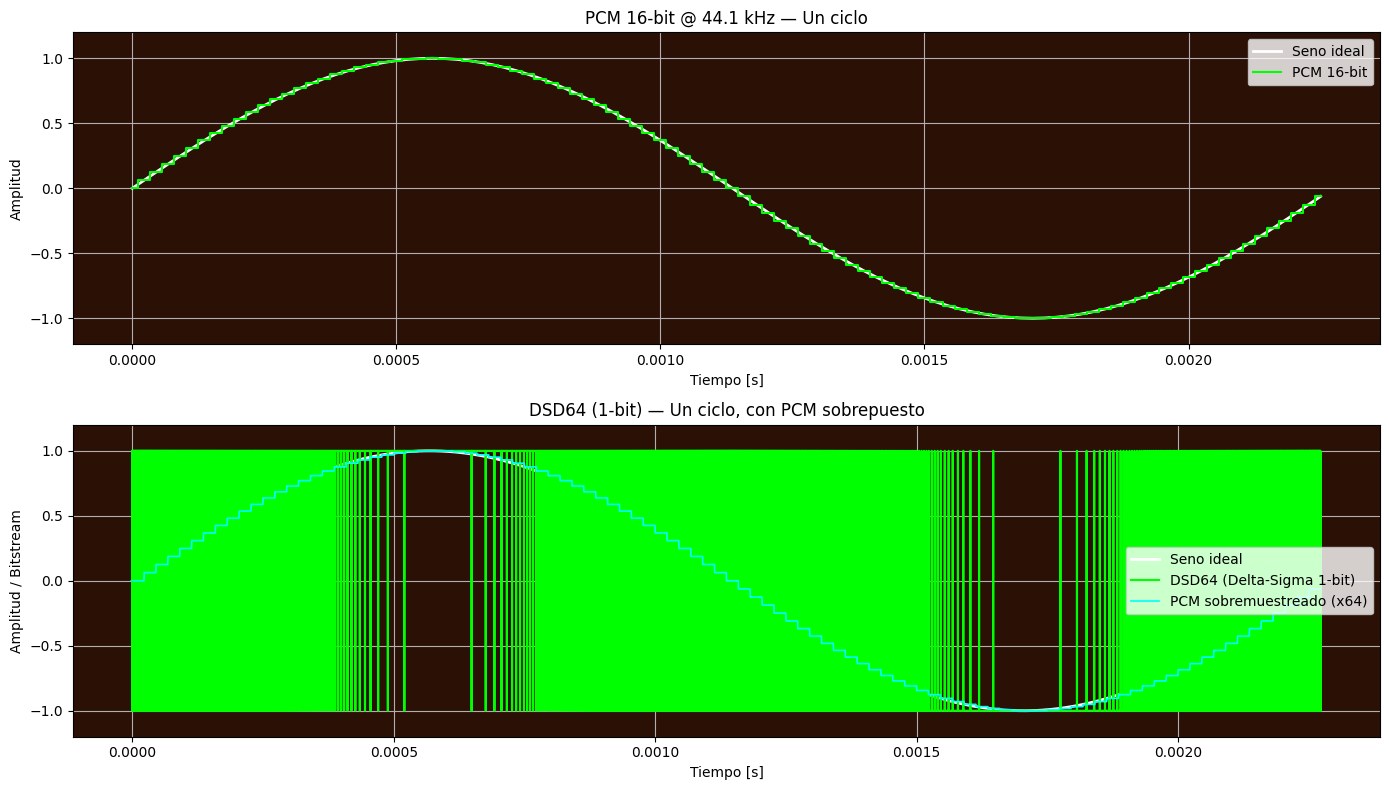

In [15]:
# =============================================================
#        GRÁFICAS TIPO “PCM vs DSD” CON PCM SOBRE LA DSD
# =============================================================
plt.figure(figsize=(14,8))

# ---------- PCM ----------
plt.subplot(2,1,1)
plt.plot(t_pcm, pcm_float, 'w', linewidth=2, label="Seno ideal")
plt.step(t_pcm, pcm_shown, where='mid', color='lime', label="PCM 16-bit")
plt.title("PCM 16-bit @ 44.1 kHz — Un ciclo")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.ylim(-1.2, 1.2)
plt.grid(True)
plt.legend()
plt.gca().set_facecolor("#2b1006")

# ---------- DSD con PCM sobrepuesto ----------
plt.subplot(2,1,2)

# Seno ideal como referencia
plt.plot(t_dsd, np.sin(2*np.pi*f*t_dsd),
         'w', linewidth=2, label="Seno ideal")

# DSD (1-bit)
plt.step(t_dsd, y, where='mid', color='lime',
         label="DSD64 (Delta-Sigma 1-bit)")

# PCM expandido (Sample & Hold) sobrepuesto
plt.plot(t_dsd, pcm_up, color='cyan', linewidth=1.2,
         label="PCM sobremuestreado (x64)")

plt.title("DSD64 (1-bit) — Un ciclo, con PCM sobrepuesto")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud / Bitstream")
plt.ylim(-1.2, 1.2)
plt.grid(True)
plt.legend()
plt.gca().set_facecolor("#2b1006")

plt.tight_layout()
plt.show()
